
[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
True satisfying assignments (bitstrings, x_0..x_{n-1}): ['000', '001', '011', '101', '110', '111']
Computed optimal Grover iterations (floor(pi/4 * sqrt(N/M))): 0
Measurement counts (most frequent likely solution):
{'011': 509, '111': 528, '100': 517, '001': 525, '000': 476, '010': 530, '101': 514, '110': 497}


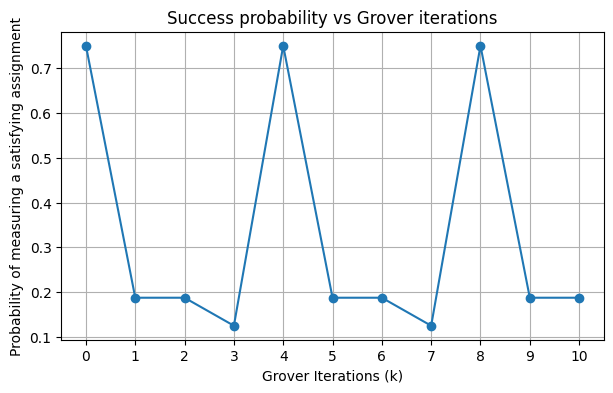

In [2]:

%pip install qiskit-aer

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import Aer
from qiskit.circuit.library import MCXGate
from qiskit.quantum_info import Statevector
import numpy as np
import matplotlib.pyplot as plt

# 1. Oracle: I'll just build here
def grover_sat_oracle(clauses, n):
    m = len(clauses)
    x = QuantumRegister(n, 'x')
    c = QuantumRegister(m, 'c')
    flag = QuantumRegister(1, 'flag')
    qc = QuantumCircuit(x, c, flag, name='3SAT-oracle')

    # For each clause: set clause ancilla to 1 if clause is FALSE
    for i, clause in enumerate(clauses):
        # Prepare controls so that controls are 1 when corresponding literal is FALSE.
        to_flip = []
        controls = []
        for literal in clause:
            var = abs(literal) - 1
            if literal > 0:
                qc.x(x[var])
                to_flip.append(var)
            controls.append(x[var])

        # Now all 'controls' are 1 exactly when clause is FALSE; use MCX to set clause ancilla.
        if len(controls) == 1:
            qc.cx(controls[0], c[i])
        else:
            qc.mcx(controls, c[i])

        # Undo the Xs we applied to prepare ctrl=1 pattern
        for var in to_flip:
            qc.x(x[var])

    if m == 0:
        # No clauses --> every assignment satisfies; flip flag always
        qc.x(flag[0])
        qc.x(flag[0]) 
    else:
        # invert clause ancillas so satisfied --> 1
        qc.x(c)
        if m == 1:
            qc.cx(c[0], flag[0])
        else:
            qc.mcx(list(c), flag[0])
        qc.x(c) 

    # Phase flip
    qc.z(flag[0])

    # Uncompute: undo the clause ancillas (reverse of above)
    # Reverse loop to maintain correct uncomputation order
    for i, clause in reversed(list(enumerate(clauses))):
        to_flip = []
        controls = []
        for literal in clause:
            var = abs(literal) - 1
            if literal > 0:
                qc.x(x[var])
                to_flip.append(var)
            controls.append(x[var])

        # Uncompute
        if len(controls) == 1:
            qc.cx(controls[0], c[i])
        else:
            qc.mcx(controls, c[i])

        for var in to_flip:
            qc.x(x[var])

    return qc

# 2. Diffusion (inversion-about-mean) operator
def diffuser(n):
    qc = QuantumCircuit(n, name='diffuser')
    qc.h(range(n))
    qc.x(range(n))
    if n == 1:
        qc.z(0)
    else:
        qc.h(n-1)
        qc.mcx(list(range(n-1)), n-1)
        qc.h(n-1)
    qc.x(range(n))
    qc.h(range(n))
    return qc


# 3. Build Grover circuit (with measurements)
def build_grover_circuit(clauses, n, iterations):
    m = len(clauses)
    x = QuantumRegister(n, 'x')
    c = QuantumRegister(m, 'c')
    flag = QuantumRegister(1, 'flag')
    creg = ClassicalRegister(n, 'c_out')
    qc = QuantumCircuit(x, c, flag, creg)

    # Initialize variables in uniform superposition
    qc.h(x)

    # Preconstruct oracle and diffuser as gates (must align qubit ordering when appending)
    oracle_circ = grover_sat_oracle(clauses, n)
    oracle_gate = oracle_circ.to_gate(label='Oracle')
    diff_gate = diffuser(n).to_gate(label='Diffusion')

    # Append iterations
    for _ in range(iterations):
        # oracle expects qubits ordered [x..., c..., flag]
        qc.append(oracle_gate, qc.qubits[: n + m + 1])
        qc.append(diff_gate, qc.qubits[:n])

    # measurement of variable register
    qc.measure(x, creg)
    return qc

# 4. Execute Grover and return counts (uses Aer qasm_simulator)
def run_grover_counts(clauses, n, iterations, shots=2048, seed_simulator=None):
    qc = build_grover_circuit(clauses, n, iterations)
    backend = Aer.get_backend('aer_simulator')
    t_qc = transpile(qc, backend=backend)
    result = backend.run(t_qc, shots=shots, seed_simulator=seed_simulator).result()
    counts = result.get_counts()
    return counts, qc

# 5. Compute success probability vs iterations using statevector simulation
def success_probability_vs_iterations(clauses, n, max_iter=12):
    
    good_states = []
    for i in range(2**n):
        bits = f"{i:0{n}b}"
        sat = True
        for clause in clauses:
            clause_val = False
            for literal in clause:
                var = abs(literal) - 1
                val = (bits[var] == '1')
                if literal < 0:
                    val = not val
                clause_val = clause_val or val
            sat = sat and clause_val
        if sat:
            good_states.append(bits)

    probs = []
    backend = Aer.get_backend('statevector_simulator')
    for k in range(max_iter + 1):
        m = len(clauses)
        x = QuantumRegister(n, 'x')
        c = QuantumRegister(m, 'c')
        flag = QuantumRegister(1, 'flag')
        circ = QuantumCircuit(x, c, flag)
        circ.h(x)
        oracle_gate = grover_sat_oracle(clauses, n).to_gate()
        diff_gate = diffuser(n).to_gate()
        for _ in range(k):
            circ.append(oracle_gate, circ.qubits[: n + m + 1])
            circ.append(diff_gate, circ.qubits[: n])
        t_circ = transpile(circ, backend=backend)
        job = backend.run(t_circ)
        sv = job.result().get_statevector()
        p = 0.0
        for bits in good_states:
            idx = int(bits, 2)
            p += np.abs(sv[idx])**2
        probs.append(p)
    return probs, good_states

# 6. Compute optimal Grover iterations
def optimal_iterations(n, num_solutions):
    if num_solutions == 0:
        return 0
    N = 2**n
    return int(np.floor(np.pi / 4 * np.sqrt(N / num_solutions)))

# 7. Test and produce outputs and plot
if __name__ == "__main__":
    # Example instance: (x_1 OR x_2' OR x_3) AND (x_1' OR x_2 OR x_3)
    clauses = [(1, -2, 3), (-1, 2, 3)]
    n = 3

    true_solutions = []
    for i in range(2**n):
        bits = f"{i:0{n}b}"
        sat = True
        for clause in clauses:
            clause_val = False
            for literal in clause:
                var = abs(literal) - 1
                val = (bits[var] == '1')
                if literal < 0:
                    val = not val
                clause_val = clause_val or val
            sat = sat and clause_val
        if sat:
            true_solutions.append(bits)

    print("True satisfying assignments (bitstrings, x_0..x_{n-1}):", true_solutions)

    k_opt = optimal_iterations(n, len(true_solutions))
    print("Computed optimal Grover iterations (floor(pi/4 * sqrt(N/M))):", k_opt)

    counts, qc = run_grover_counts(clauses, n, iterations=k_opt, shots=4096, seed_simulator=42)
    print("Measurement counts (most frequent likely solution):")
    print(counts)

    max_iter = 10
    probs, good_states = success_probability_vs_iterations(clauses, n, max_iter=max_iter)
    plt.figure(figsize=(7,4))
    plt.plot(range(len(probs)), probs, marker='o')
    plt.xticks(range(len(probs)))
    plt.xlabel("Grover Iterations (k)")
    plt.ylabel("Probability of measuring a satisfying assignment")
    plt.title("Success probability vs Grover iterations")
    plt.grid(True)
    plt.show()


The oracle implements the Boolean 3-SAT evaluation in a reversible way using clause ancillas and one final “flag” qubit. So, essentially, what we're doing is a satisfying assignment should cause the oracle to apply a phase flip, while nonsatisfying assignments should leave the global phase unchanged. For each clause, the oracle first determines when that clause is false. A clause is false only when all three literals are false simultaneously, so the circuit temporarily applies X gates to any positive literal to convert the condition “literal is false” into the qubit pattern “control equals 1.” Once the qubits are in this standardized pattern (all controls = 1 when the clause is false), an MCX gate writes the clause result into a dedicated ancilla qubit.Then, after that, the temporary X gates are undone so the variable register returns to its original form.

Then, after all clauses have been individually checked, the circuit flips the clause ancillas so that satisfied clauses correspond to the ancilla value 1. If all clauses are satisfied simultaneously, all clause ancillas equal 1, so a multi-controlled x sets the final flag qubit to 1. A Z gate on the flag then introduces the phase kickback that characterizes Grover’s oracle in which only the satisfying assignments acquire a negative phase. Finally, the oracle “uncomputes” everything by repeating the clause-ancilla logic in reverse. This restores the clause ancillas and variable qubits to their initial values, ensuring the oracle is a clean, reversible unitary. The result is a correct 3-SAT oracle that marks valid assignments and leaves all other computational basis states unchanged.

For the iteration count, Grover’s algorithm amplifies the amplitudes of the marked (satisfying) states through repeated applications of the Grover operator. The number of optimal iterations depends on the fraction of solutions in the search space. So, if we have n variables, the search space contains N = 2^n possible assignments. Let M be the number of satisfying assignments for the given 3-SAT instance. Grover’s amplitude amplification theory shows that the probability of measuring a solution increases sinusoidally and reaches its first maximum after approximately k = floor(pi/4 * sqrt(N/M)). In the code, after enumerating all the 2^n assignments, te code computes M exactly and substitute it into this formula. For the example, n=3, so N=8, M= (computed from brute-force). Plugging these values into the expression gives the optimal number of Grover iterations that is then used by the circuit. Using this theoretically optimal iteration count ensures that the success probability is maximized before the amplitude begins to rotate away again due oscillations. 